In [8]:
import pandas as pd

df = pd.read_csv("../energydata_complete.csv")

print(df.shape)
df.head()

(19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [10]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [11]:
df["Appliances"].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

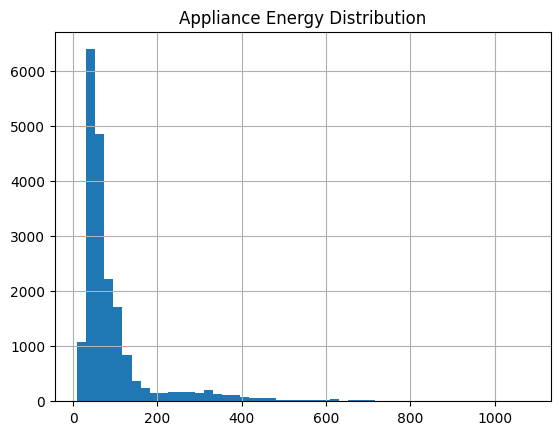

In [12]:
import matplotlib.pyplot as plt

df["Appliances"].hist(bins=50)

plt.title("Appliance Energy Distribution")
plt.show()

In [13]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['week'] = df['date'].dt.isocalendar().week
df['week_of_month'] = (df['date'].dt.day - 1) // 7 + 1
df['is_weekend'] = df['date'].dt.dayofweek >= 5

In [14]:
corr = df.corr(numeric_only=True)

corr["Appliances"].sort_values(ascending=False)


Appliances       1.000000
hour             0.216792
lights           0.197278
T2               0.120073
T6               0.117638
T_out            0.099155
Windspeed        0.087122
RH_1             0.086031
T3               0.085060
T1               0.055447
T4               0.040281
T8               0.039572
RH_3             0.036292
T7               0.025801
T5               0.019384
is_weekend       0.017437
RH_4             0.016965
Tdewpoint        0.015353
T9               0.010010
RH_5             0.006955
week_of_month    0.006851
Visibility       0.000230
rv2             -0.011145
rv1             -0.011145
week            -0.011356
Press_mm_hg     -0.034885
RH_9            -0.051462
RH_7            -0.055642
RH_2            -0.060465
RH_6            -0.083178
RH_8            -0.094039
RH_out          -0.152282
Name: Appliances, dtype: float64

<Axes: >

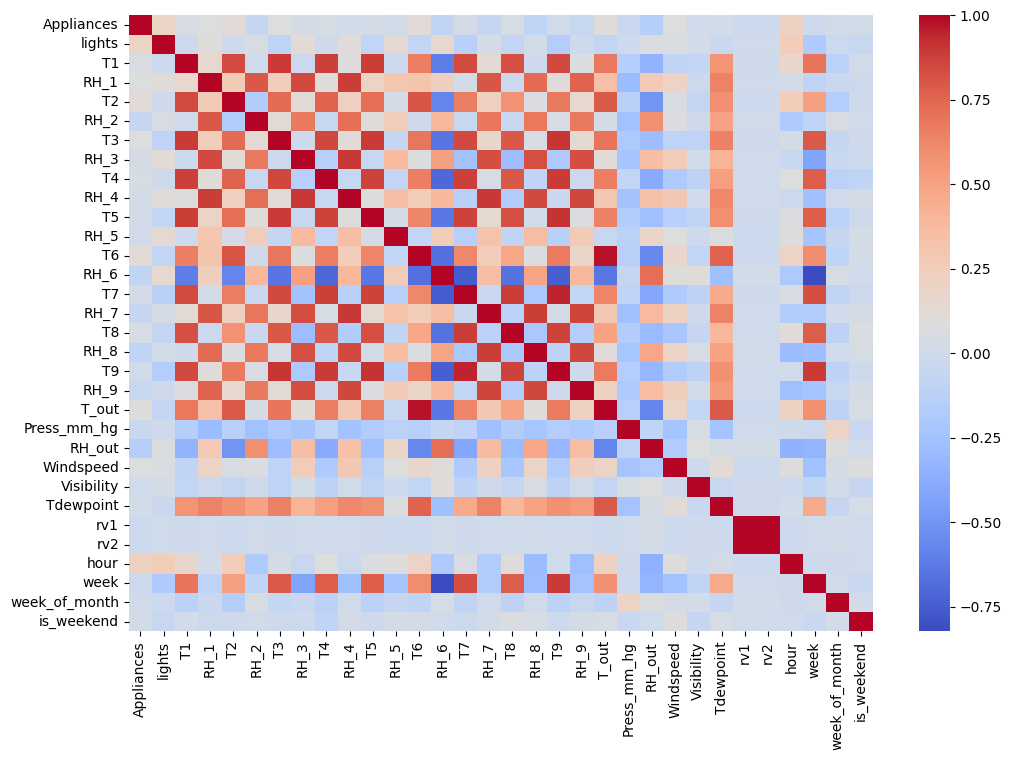

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

In [ ]:
cluster_features = [
    'T1',
    'RH_1',
    'T_out',
    'RH_out'
]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_cluster_data = scaler.fit_transform(
    df[cluster_features]
)

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.2,
    min_samples=20
)

df['cluster'] = dbscan.fit_predict(
    scaled_cluster_data
)

In [23]:
df.groupby("cluster")["Appliances"].mean()
df['cluster'].value_counts()

cluster
-1     10926
 4      3933
 6       378
 19      363
 40      225
       ...  
 70       19
 5        15
 34       15
 12       13
 79       13
Name: count, Length: 100, dtype: int64

In [ ]:
features = [
    'T1','RH_1',
    'T2','RH_2',
    'T3','RH_3',
    'T4','T5','T6','T7','T8',
    'RH_8','T9','RH_9',
    'T_out',
    'Tdewpoint',
    'hour',
    'week',
    'week_of_month',
    'is_weekend'
]

In [25]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df["Appliances"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [28]:
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)

pred_etr = etr.predict(X_test)

In [34]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    
evaluate_model(
    "Linear Regression",
    y_test,
    pred_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

evaluate_model(
    "Extra Trees",
    y_test,
    pred_etr
)


Linear Regression
MAE  : 53.35
RMSE : 92.35
R²   : 0.1477

Random Forest
MAE  : 29.42
RMSE : 63.64
R²   : 0.5953

Extra Trees
MAE  : 26.21
RMSE : 58.27
R²   : 0.6607
